# 전처리 2단계 — 파생변수: 실효습도 v3 (6년 확장 + v1 흐름 유지)

`PREP_02_실효습도.ipynb`의 기존 흐름을 최대한 유지하되, 처리 대상이 **2025년 1개년 → 2020~2025년 6개년**으로 늘어난 상황에 맞게 메모리 효율과 검증 방식을 보강한 버전입니다.

## 핵심 변경점

- 월별 Parquet 파티션 단위로 읽고 저장합니다.
- 연속 월(`2월→3월→4월→5월`)에서는 이전 월 마지막 4일을 버퍼로 이어 붙입니다.
- 비연속 월(`5월→다음 해 2월`)에서는 버퍼를 끊어 다른 해의 5월 습도가 다음 해 2월 계산에 섞이지 않도록 합니다.
- 전체 검증은 `pandas.read_parquet()` 대신 `DuckDB`로 수행합니다.
- v1에 있던 월 경계 검증, 월별 통계, 시각화 코드를 유지·보강했습니다.

## 실효습도 공식

```text
EH = (1 - 0.7) × (H0 + 0.7×H1 + 0.7²×H2 + 0.7³×H3 + 0.7⁴×H4)
   = 0.3 × (H0 + 0.7×H1 + 0.49×H2 + 0.343×H3 + 0.2401×H4)
```


In [7]:
# BASE_PATH 설정

from pathlib import Path

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / ".project-root").exists():
            return path

    raise FileNotFoundError(".project-root 파일을 찾지 못했습니다.")

BASE_PATH = find_project_root()

In [ ]:
import pandas as pd
import numpy as np
import os, time
import warnings
import gc
warnings.filterwarnings('ignore')

# 입력: PREP_01 스케일 변환 결과
SCALED_PATH = BASE_PATH / "preprocessing" / "weather_scaled"

# 출력: 실효습도 파생변수
DERIVED_DIR = BASE_PATH / "preprocessing" / "derived"
OUTPUT_PATH = BASE_PATH / "preprocessing" / "PREP02"

DERIVED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print(f"BASE_PATH   : {BASE_PATH}")
print(f"SCALED_PATH : {SCALED_PATH}")
print(f"OUTPUT_PATH : {OUTPUT_PATH}")

BASE_PATH   : C:\SKN projects\weather
SCALED_PATH : C:\SKN projects\weather\preprocessing\weather_scaled
OUTPUT_PATH : C:\SKN projects\weather\preprocessing\derived\effective_humidity


In [9]:
# ============================================================
# 1. 처리 대상 월 및 파라미터
# ============================================================

YEARS = range(2020, 2026)
SPRING_MONTHS = [2, 3, 4, 5]

MONTHS = [f"{year}-{month:02d}" for year in YEARS for month in SPRING_MONTHS]

# 실효습도 파라미터
R = 0.7
LAGS = 5
LAG_DAYS = 4
WEIGHTS = np.array([(1 - R) * (R ** i) for i in range(LAGS)], dtype="float32")

print(f"처리 대상 월 수: {len(MONTHS)}개")
print(MONTHS)
print()
print("실효습도 가중치:", [round(float(w), 4) for w in WEIGHTS])
print(f"가중치 합: {WEIGHTS.sum():.4f}")

처리 대상 월 수: 24개
['2020-02', '2020-03', '2020-04', '2020-05', '2021-02', '2021-03', '2021-04', '2021-05', '2022-02', '2022-03', '2022-04', '2022-05', '2023-02', '2023-03', '2023-04', '2023-05', '2024-02', '2024-03', '2024-04', '2024-05', '2025-02', '2025-03', '2025-04', '2025-05']

실효습도 가중치: [0.3, 0.21, 0.147, 0.1029, 0.072]
가중치 합: 0.8319


---
## Step 1. 실효습도 계산 함수 정의

격자(`grid_id`)별로 날짜를 정렬한 뒤 `hm_mean`의 0~4일 lag를 만들고, 공식에 따라 실효습도를 계산합니다.

데이터 시작부처럼 과거 4일이 없는 경우에는 v1과 동일하게 당일 습도(`H0`)로 채웁니다.


In [10]:
def compute_eh(df: pd.DataFrame, weights=WEIGHTS) -> pd.DataFrame:
    """
    df: grid_id, date, hm_mean 컬럼 포함.
        반드시 grid_id, date 기준으로 정렬된 상태여야 함.

    반환: grid_id, date, effective_humidity 컬럼을 가진 DataFrame
    """
    g = df.groupby("grid_id", sort=False)["hm_mean"]
    h0 = df["hm_mean"]

    eh = (
        weights[0] * h0
        + weights[1] * g.shift(1).fillna(h0)
        + weights[2] * g.shift(2).fillna(h0)
        + weights[3] * g.shift(3).fillna(h0)
        + weights[4] * g.shift(4).fillna(h0)
    )

    result = df[["grid_id", "date"]].copy()
    result["effective_humidity"] = eh.astype("float32")
    return result


def is_contiguous_month(prev_month, curr_month: str) -> bool:
    """
    prev_month와 curr_month가 실제로 바로 다음 달인지 확인합니다.
    예: 2020-02 -> 2020-03 True
        2020-05 -> 2021-02 False
    """
    if prev_month is None:
        return False

    prev = pd.Period(prev_month, freq="M")
    curr = pd.Period(curr_month, freq="M")
    return curr == prev + 1


print("함수 정의 완료")

함수 정의 완료


In [11]:
# ============================================================
# 1-1. 소규모 예시로 공식 검증
# ============================================================
test_data = pd.DataFrame({
    "grid_id": ["A"] * 5,
    "date": pd.date_range("2025-02-01", periods=5),
    "hm_mean": [88.2, 78.7, 48.9, 48.3, 49.7]
})

test_result = compute_eh(test_data)

print("=== 계산 예시 검증 ===")
print(test_result.merge(test_data, on=["grid_id", "date"])[["date", "hm_mean", "effective_humidity"]].to_string(index=False))
print()

h0 = 88.2
manual_day1 = 0.3 * (h0 + 0.7*h0 + 0.49*h0 + 0.343*h0 + 0.2401*h0)
print(f"1일차 수동 계산: {manual_day1:.2f}%")
print(f"1일차 함수 계산: {test_result.loc[0, 'effective_humidity']:.2f}%")

=== 계산 예시 검증 ===
      date  hm_mean  effective_humidity
2025-02-01     88.2           73.376228
2025-02-02     78.7           67.467888
2025-02-03     48.9           52.716476
2025-02-04     48.3           48.882729
2025-02-05     49.7           46.692577

1일차 수동 계산: 73.38%
1일차 함수 계산: 73.38%


---
## Step 2. 전체 데이터 실효습도 계산

월별로 처리하되, 월 경계에서 실효습도가 끊기지 않도록 이전 월 마지막 4일을 버퍼로 사용합니다.

주의할 점은 `2020-05 → 2021-02`처럼 실제로 연속된 달이 아닌 경우입니다. 이때는 버퍼를 사용하지 않아야 합니다.


In [12]:
# ============================================================
# 2. 월별 처리 + 연속 월에만 4일 버퍼 이월
# ============================================================
start_total = time.time()

buffer = None
prev_month = None

for m in MONTHS:
    start_m = time.time()
    print(f"[{m}] 처리 시작")

    # 1) 해당 월 데이터 읽기
    df_m = pd.read_parquet(
        SCALED_PATH,
        filters=[("month", "==", m)],
        columns=["grid_id", "date", "hm_mean"],
        engine="pyarrow"
    )

    df_m["date"] = pd.to_datetime(df_m["date"])
    print(f"  원본 행 수: {len(df_m):,}")

    # 2) 이전 월과 연속일 때만 버퍼 붙이기
    use_buffer = buffer is not None and is_contiguous_month(prev_month, m)

    if use_buffer:
        df_work = pd.concat([buffer, df_m], ignore_index=True)
        print(f"  버퍼 사용: {len(buffer):,}행 ({prev_month} 마지막 {LAG_DAYS}일)")
    else:
        df_work = df_m
        buffer = None
        print("  버퍼 미사용: 첫 월 또는 비연속 월")

    # 3) 정렬 후 실효습도 계산
    df_work = df_work.sort_values(["grid_id", "date"]).reset_index(drop=True)
    df_eh = compute_eh(df_work)

    # 4) 현재 월 결과만 남기기
    month_start = pd.Timestamp(f"{m}-01")
    month_end = month_start + pd.offsets.MonthEnd(0)

    df_result = df_eh[
        (df_eh["date"] >= month_start) &
        (df_eh["date"] <= month_end)
    ].copy()

    # 5) 다음 달 계산용 버퍼 생성
    last_dates = sorted(df_m["date"].unique())[-LAG_DAYS:]
    buffer = df_m[df_m["date"].isin(last_dates)][["grid_id", "date", "hm_mean"]].copy()
    prev_month = m

    # 6) 월별 파티션 저장
    out_dir = OUTPUT_PATH / f"month={m}"
    out_dir.mkdir(parents=True, exist_ok=True)

    df_result.to_parquet(
        out_dir / "data.parquet",
        index=False,
        engine="pyarrow",
        compression="snappy"
    )

    elapsed = time.time() - start_m
    print(f"  저장 행 수: {len(df_result):,}")
    print(f"  저장 위치: {out_dir}")
    print(f"  처리 시간: {elapsed:.1f}초")

    del df_m, df_work, df_eh, df_result
    gc.collect()

print()
print(f"전체 완료: {(time.time() - start_total) / 60:.1f}분")
print(f"저장 위치: {OUTPUT_PATH}")

[2020-02] 처리 시작
  원본 행 수: 7,917,029
  버퍼 미사용: 첫 월 또는 비연속 월
  저장 행 수: 7,917,029
  저장 위치: C:\SKN projects\weather\preprocessing\derived\effective_humidity\month=2020-02
  처리 시간: 8.7초
[2020-03] 처리 시작
  원본 행 수: 8,463,031
  버퍼 사용: 1,092,004행 (2020-02 마지막 4일)
  저장 행 수: 8,463,031
  저장 위치: C:\SKN projects\weather\preprocessing\derived\effective_humidity\month=2020-03
  처리 시간: 10.5초
[2020-04] 처리 시작
  원본 행 수: 8,190,030
  버퍼 사용: 1,092,004행 (2020-03 마지막 4일)
  저장 행 수: 8,190,030
  저장 위치: C:\SKN projects\weather\preprocessing\derived\effective_humidity\month=2020-04
  처리 시간: 10.5초
[2020-05] 처리 시작
  원본 행 수: 8,463,031
  버퍼 사용: 1,092,004행 (2020-04 마지막 4일)
  저장 행 수: 8,463,031
  저장 위치: C:\SKN projects\weather\preprocessing\derived\effective_humidity\month=2020-05
  처리 시간: 10.8초
[2021-02] 처리 시작
  원본 행 수: 7,644,028
  버퍼 미사용: 첫 월 또는 비연속 월
  저장 행 수: 7,644,028
  저장 위치: C:\SKN projects\weather\preprocessing\derived\effective_humidity\month=2021-02
  처리 시간: 9.0초
[2021-03] 처리 시작
  원본 행 수: 8,463,031
  버퍼 사용: 1,092

---
## Step 3. DuckDB 기반 결과 검증

6년치 데이터를 `pd.read_parquet()`로 전체 로드하면 메모리가 부족할 수 있습니다.  
따라서 검증은 DuckDB로 Parquet을 직접 스캔하여 집계 결과만 계산합니다.


In [13]:
# ============================================================
# 3. DuckDB 검증 설정
# ============================================================
import duckdb

con = duckdb.connect()

eh_glob = (OUTPUT_PATH / "**" / "*.parquet").as_posix()
weather_glob = (SCALED_PATH / "**" / "*.parquet").as_posix()

print(f"EH parquet glob      : {eh_glob}")
print(f"Weather parquet glob : {weather_glob}")

EH parquet glob      : C:/SKN projects/weather/preprocessing/derived/effective_humidity/**/*.parquet
Weather parquet glob : C:/SKN projects/weather/preprocessing/weather_scaled/**/*.parquet


In [14]:
# ============================================================
# 3-1. 기본 정보 및 범위 검증
# ============================================================
print("=== 기본 정보 ===")

basic = con.execute(f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT(DISTINCT grid_id) AS grid_count,
        MIN(CAST(date AS DATE)) AS min_date,
        MAX(CAST(date AS DATE)) AS max_date,
        SUM(CASE WHEN effective_humidity IS NULL THEN 1 ELSE 0 END) AS null_count
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
""").fetchdf()

display(basic)

print("=== 실효습도 범위 검증 ===")
eh_stats = con.execute(f"""
    SELECT
        MIN(effective_humidity) AS min_eh,
        AVG(effective_humidity) AS mean_eh,
        MAX(effective_humidity) AS max_eh
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
""").fetchdf()

display(eh_stats)

min_eh = eh_stats.loc[0, "min_eh"]
max_eh = eh_stats.loc[0, "max_eh"]

if min_eh >= 0 and max_eh <= 100:
    print("=> 실효습도 범위 정상: 0~100%")
else:
    print("=> 실효습도 범위 이상: 확인 필요")

=== 기본 정보 ===


,row_count,grid_count,min_date,max_date,null_count
0,197106722,273001,2020-02-01,2025-05-31,0.0


=== 실효습도 범위 검증 ===


,min_eh,mean_eh,max_eh
0,18.085827,51.465417,82.561043


=> 실효습도 범위 정상: 0~100%


In [15]:
# ============================================================
# 3-2. 샘플 3행 출력
# ============================================================
print("=== 변환 후 샘플 3행 ===")

sample = con.execute(f"""
    SELECT *
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
    LIMIT 3
""").fetchdf()

display(sample)

=== 변환 후 샘플 3행 ===


,grid_id,date,effective_humidity,month
0,10007_19696,2020-02-01,67.427933,2020-02
1,10007_19696,2020-02-02,63.766315,2020-02
2,10007_19696,2020-02-03,51.165955,2020-02


In [16]:
# ============================================================
# 3-3. 월별 실효습도 통계
# ============================================================
print("=== 월별 실효습도 통계 ===")

monthly = con.execute(f"""
    SELECT
        month,
        COUNT(*) AS row_count,
        MIN(effective_humidity) AS min_eh,
        AVG(effective_humidity) AS mean_eh,
        MAX(effective_humidity) AS max_eh
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
    GROUP BY month
    ORDER BY month
""").fetchdf()

monthly[["min_eh", "mean_eh", "max_eh"]] = monthly[["min_eh", "mean_eh", "max_eh"]].round(2)
display(monthly)

=== 월별 실효습도 통계 ===


,month,row_count,min_eh,mean_eh,max_eh
0,2020-02,7917029,26.330000,55.17,80.599998
1,2020-03,8463031,26.639999,50.76,81.029999
2,2020-04,8190030,24.780001,46.32,75.730003
3,2020-05,8463031,25.700001,59.34,81.559998
4,2021-02,7644028,18.590000,46.40,79.360001
5,2021-03,8463031,24.830000,54.54,75.349998
6,2021-04,8190030,25.459999,47.88,72.480003
7,2021-05,8463031,27.469999,59.05,79.870003
8,2022-02,7644028,21.010000,43.65,77.750000
9,2022-03,8463031,18.620001,43.72,65.629997


---
## Step 4. 월 경계 연속성 확인

샘플 격자 하나를 골라 `2월 말 → 3월 초` 구간에서 실효습도가 자연스럽게 이어지는지 확인합니다.

아래 코드는 기본적으로 2025년 경계를 확인하지만, `CHECK_YEAR`를 바꾸면 다른 연도도 확인할 수 있습니다.


In [17]:
# ============================================================
# 4. 월 경계 확인: 2월 말 -> 3월 초
# ============================================================
CHECK_YEAR = 2025

sample_grid = con.execute(f"""
    SELECT grid_id
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
    WHERE month = '{CHECK_YEAR}-03'
    LIMIT 1
""").fetchone()[0]

print(f"샘플 grid_id: {sample_grid}")

boundary = con.execute(f"""
    WITH eh AS (
        SELECT
            grid_id,
            CAST(date AS DATE) AS date,
            effective_humidity,
            month
        FROM read_parquet('{eh_glob}', hive_partitioning=true)
        WHERE grid_id = '{sample_grid}'
          AND CAST(date AS DATE) BETWEEN DATE '{CHECK_YEAR}-02-26' AND DATE '{CHECK_YEAR}-03-03'
    ),
    hm AS (
        SELECT
            grid_id,
            CAST(date AS DATE) AS date,
            hm_mean
        FROM read_parquet('{weather_glob}', hive_partitioning=true)
        WHERE grid_id = '{sample_grid}'
          AND CAST(date AS DATE) BETWEEN DATE '{CHECK_YEAR}-02-26' AND DATE '{CHECK_YEAR}-03-03'
    )
    SELECT
        eh.grid_id,
        eh.date,
        hm.hm_mean,
        eh.effective_humidity,
        eh.month
    FROM eh
    LEFT JOIN hm USING (grid_id, date)
    ORDER BY eh.date
""").fetchdf()

boundary[["hm_mean", "effective_humidity"]] = boundary[["hm_mean", "effective_humidity"]].round(2)
display(boundary)

print("해석: 실효습도(EH)는 당일 습도(hm_mean)보다 변화가 완만해야 합니다.")
print("     월 경계에서도 2월 말 습도 이력이 3월 초 EH에 반영됩니다.")

샘플 grid_id: 10007_19696


,grid_id,date,hm_mean,effective_humidity,month
0,10007_19696,2025-02-26,53.380001,45.810001,2025-02
1,10007_19696,2025-02-27,49.279999,44.470001,2025-02
2,10007_19696,2025-02-28,62.680000,47.500000,2025-02
3,10007_19696,2025-03-01,78.699997,54.250000,2025-03
4,10007_19696,2025-03-02,79.209999,58.419998,2025-03
5,10007_19696,2025-03-03,70.800003,59.439999,2025-03


해석: 실효습도(EH)는 당일 습도(hm_mean)보다 변화가 완만해야 합니다.
     월 경계에서도 2월 말 습도 이력이 3월 초 EH에 반영됩니다.


---
## Step 5. 시각화

v1에 있던 그래프 생성 코드를 유지하되, 전체 데이터를 메모리에 올리지 않고 DuckDB로 필요한 집계/샘플만 가져와 시각화합니다.


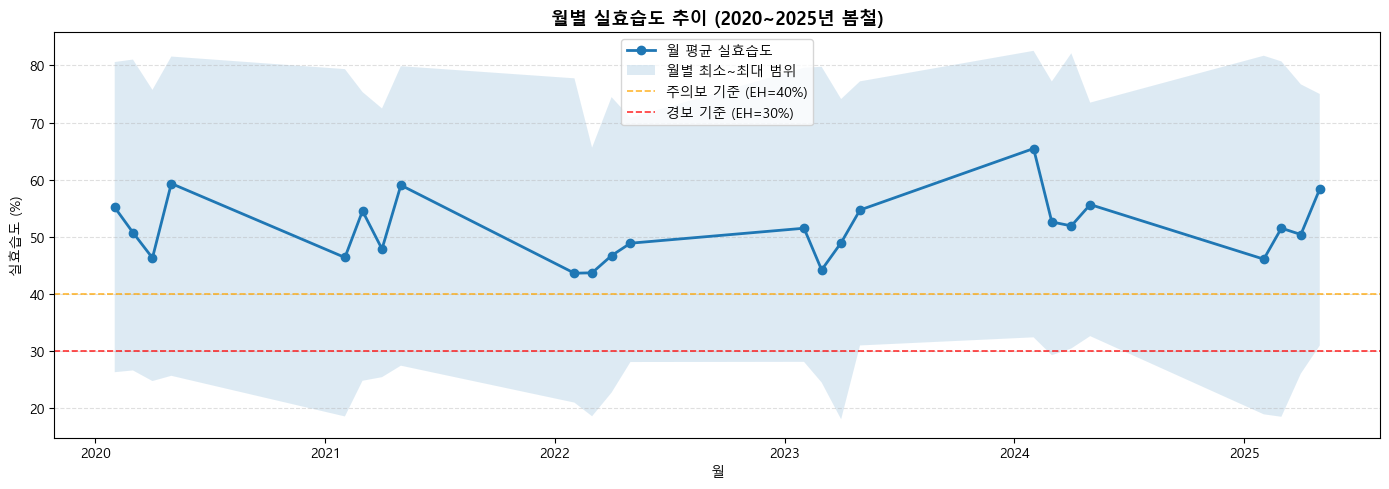

저장 완료: C:\SKN projects\weather\preprocessing\derived\effective_humidity\effective_humidity_monthly_trend.png


In [ ]:
# ============================================================
# 5-1. 월별 평균 실효습도 추이 그래프
# ============================================================
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

monthly_plot = monthly.copy()
monthly_plot["month_dt"] = pd.to_datetime(monthly_plot["month"] + "-01")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_plot["month_dt"], monthly_plot["mean_eh"], marker="o", linewidth=2, label="월 평균 실효습도")
ax.fill_between(monthly_plot["month_dt"], monthly_plot["min_eh"], monthly_plot["max_eh"], alpha=0.15, label="월별 최소~최대 범위")

ax.axhline(40, color="orange", linewidth=1.2, linestyle="--", alpha=0.8, label="주의보 기준 (EH=40%)")
ax.axhline(30, color="red", linewidth=1.2, linestyle="--", alpha=0.8, label="경보 기준 (EH=30%)")

ax.set_title("월별 실효습도 추이 (2020~2025년 봄철)", fontsize=13, fontweight="bold")
ax.set_xlabel("월")
ax.set_ylabel("실효습도 (%)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()

fig_path = OUTPUT_PATH / "PREP_02_실효습도시계열.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"저장 완료: {fig_path}")

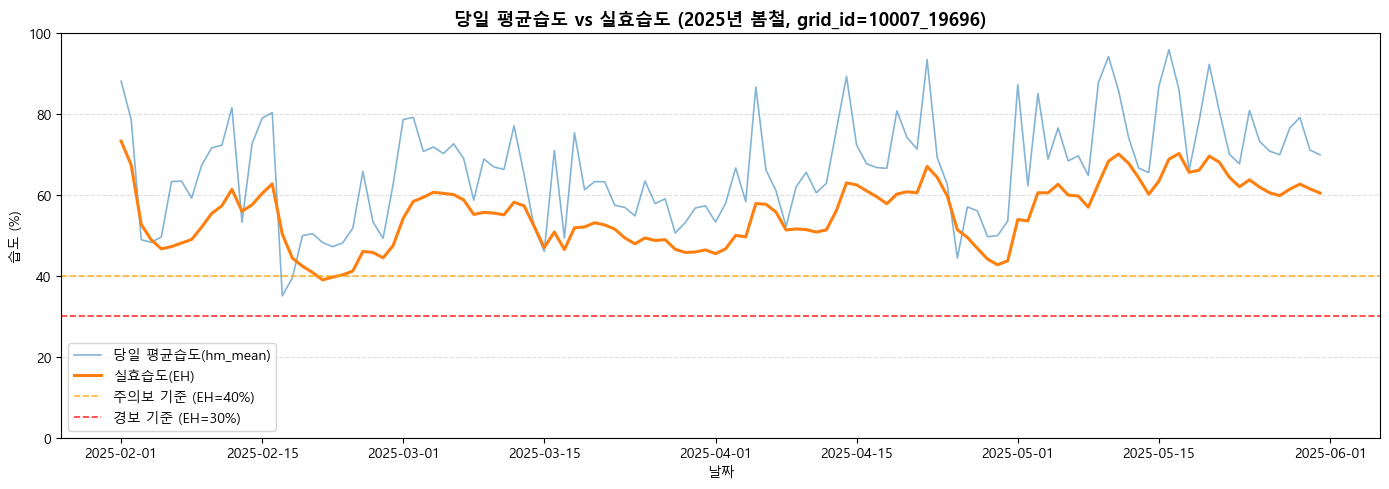

저장 완료: C:\SKN projects\weather\preprocessing\derived\effective_humidity\effective_humidity_sample_grid_2025.png


In [19]:
# ============================================================
# 5-2. 특정 격자의 당일 평균습도 vs 실효습도 시계열
# ============================================================
PLOT_YEAR = 2025

sample_grid = con.execute(f"""
    SELECT grid_id
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
    WHERE month = '{PLOT_YEAR}-02'
    LIMIT 1
""").fetchone()[0]

sample_series = con.execute(f"""
    WITH eh AS (
        SELECT
            grid_id,
            CAST(date AS DATE) AS date,
            effective_humidity
        FROM read_parquet('{eh_glob}', hive_partitioning=true)
        WHERE grid_id = '{sample_grid}'
          AND month BETWEEN '{PLOT_YEAR}-02' AND '{PLOT_YEAR}-05'
    ),
    hm AS (
        SELECT
            grid_id,
            CAST(date AS DATE) AS date,
            hm_mean
        FROM read_parquet('{weather_glob}', hive_partitioning=true)
        WHERE grid_id = '{sample_grid}'
          AND month BETWEEN '{PLOT_YEAR}-02' AND '{PLOT_YEAR}-05'
    )
    SELECT
        eh.grid_id,
        eh.date,
        hm.hm_mean,
        eh.effective_humidity
    FROM eh
    LEFT JOIN hm USING (grid_id, date)
    ORDER BY eh.date
""").fetchdf()

sample_series["date"] = pd.to_datetime(sample_series["date"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_series["date"], sample_series["hm_mean"],
        alpha=0.55, linewidth=1.2, label="당일 평균습도(hm_mean)")
ax.plot(sample_series["date"], sample_series["effective_humidity"],
        linewidth=2.2, label="실효습도(EH)")

ax.axhline(40, color="orange", linewidth=1.2, linestyle="--", alpha=0.8, label="주의보 기준 (EH=40%)")
ax.axhline(30, color="red", linewidth=1.2, linestyle="--", alpha=0.8, label="경보 기준 (EH=30%)")

ax.set_title(f"당일 평균습도 vs 실효습도 ({PLOT_YEAR}년 봄철, grid_id={sample_grid})", fontsize=13, fontweight="bold")
ax.set_xlabel("날짜")
ax.set_ylabel("습도 (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()

fig_path = OUTPUT_PATH / f"effective_humidity_sample_grid_{PLOT_YEAR}.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"저장 완료: {fig_path}")

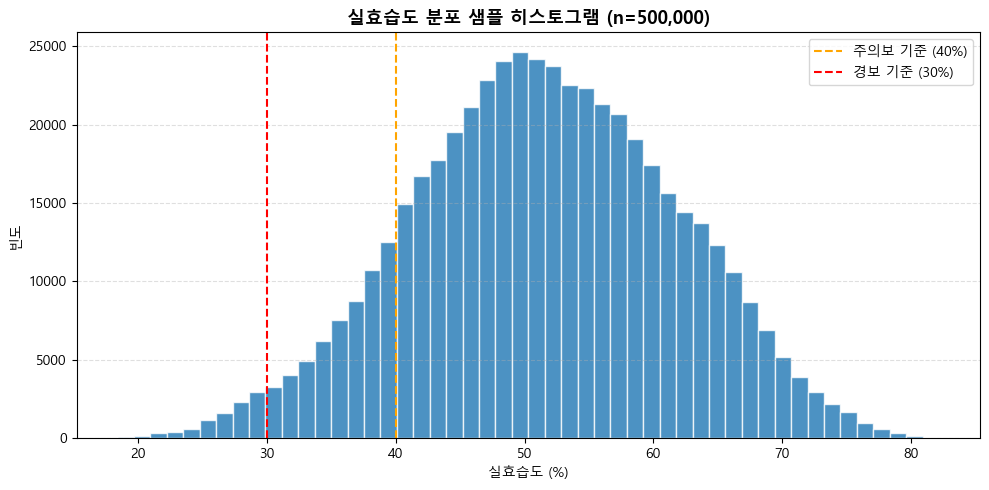

저장 완료: C:\SKN projects\weather\preprocessing\derived\effective_humidity\effective_humidity_hist_sample.png


In [ ]:
# ============================================================
# 5-3. 실효습도 분포 히스토그램
#      전체를 pandas로 읽지 않고 DuckDB에서 샘플링해서 시각화
# ============================================================
SAMPLE_N = 500_000

hist_sample = con.execute(f"""
    SELECT effective_humidity
    FROM read_parquet('{eh_glob}', hive_partitioning=true)
    USING SAMPLE {SAMPLE_N} ROWS
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(hist_sample["effective_humidity"], bins=50, alpha=0.8, edgecolor="white")
ax.axvline(40, color="orange", linewidth=1.5, linestyle="--", label="주의보 기준 (40%)")
ax.axvline(30, color="red", linewidth=1.5, linestyle="--", label="경보 기준 (30%)")

ax.set_title(f"실효습도 분포 샘플 히스토그램 (n={len(hist_sample):,})", fontsize=13, fontweight="bold")
ax.set_xlabel("실효습도 (%)")
ax.set_ylabel("빈도")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()

fig_path = OUTPUT_PATH / "PREP_02_실효습도분포샘플히스토그램.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"저장 완료: {fig_path}")

---
## 최종 요약


In [21]:
print("=" * 70)
print("  파생변수 1: 실효습도(EH) 생성 완료 — v3")
print("=" * 70)
print(f"""
  공식
  EH = 0.3 × (H0 + 0.7×H1 + 0.49×H2 + 0.343×H3 + 0.2401×H4)

  처리 범위
  - 2020~2025년 2~5월 봄철 전체
  - 총 {len(MONTHS)}개 월 파티션 처리

  처리 방식
  - 월별 처리 + 4일 버퍼 이월
  - 연속 월만 버퍼 사용: 2월→3월→4월→5월
  - 비연속 월은 버퍼 차단: 5월→다음 해 2월

  저장 위치
  - {OUTPUT_PATH}

  검증 방식
  - DuckDB로 전체 Parquet 집계 검증
  - pandas 전체 로드 없음
  - 월별 통계, 월 경계 연속성, 샘플 시계열 그래프 확인

  산불위험 활용
  - 실효습도 < 40%: 대형산불 주의보 기준 참고
  - 실효습도 < 30%: 대형산불 경보 기준 참고
  - DWI 또는 FFDRI 계열 기상위험지수 계산에 사용
""")
print("=" * 70)

  파생변수 1: 실효습도(EH) 생성 완료 — v3

  공식
  EH = 0.3 × (H0 + 0.7×H1 + 0.49×H2 + 0.343×H3 + 0.2401×H4)

  처리 범위
  - 2020~2025년 2~5월 봄철 전체
  - 총 24개 월 파티션 처리

  처리 방식
  - 월별 처리 + 4일 버퍼 이월
  - 연속 월만 버퍼 사용: 2월→3월→4월→5월
  - 비연속 월은 버퍼 차단: 5월→다음 해 2월

  저장 위치
  - C:\SKN projects\weather\preprocessing\derived\effective_humidity

  검증 방식
  - DuckDB로 전체 Parquet 집계 검증
  - pandas 전체 로드 없음
  - 월별 통계, 월 경계 연속성, 샘플 시계열 그래프 확인

  산불위험 활용
  - 실효습도 < 40%: 대형산불 주의보 기준 참고
  - 실효습도 < 30%: 대형산불 경보 기준 참고
  - DWI 또는 FFDRI 계열 기상위험지수 계산에 사용

